<a href="https://colab.research.google.com/github/victory113/dqn-lunar-lander/blob/main/dqn_lunar_lander.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DQN Lunar Lander — CSCI 3385 Assignment 10


In [ ]:
!pip install gymnasium[box2d] torch numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 58.8 MB/s eta 0:00:00


## Imports

In [ ]:
import gymnasium as gym
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque, namedtuple
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Hyperparameters (Member 2 - Nicola)

In [ ]:
# Member 2: All tunable values in one place
# Number of full games to train.
NUM_EPISODES = 700

# Upper bound on steps in one episode.
MAX_STEPS_PER_EPISODE = 1000

# Minibatch size sampled from replay buffer each gradient step.
BATCH_SIZE = 64

# Optimizer step size
LEARNING_RATE = 5e-4

# Discount factor for future rewards
GAMMA = 0.99

# Epsilon-greedy exploration schedule
EPSILON_START = 1.0
EPSILON_END = 0.01

# Multiplicative decay per episode
EPSILON_DECAY = 0.995

# Smoothing window used in plots (for cleaner trend lines).
PLOT_MOVING_AVG_WINDOW = 25

BUFFER_SIZE = 100_000
MIN_BUFFER_SIZE = 1000

TARGET_UPDATE_FREQ = 10
TAU = 0.005 # Soft update parameter for target network

SEED = 42

## Replay Buffer (Member 3 - Pacifique)

In [ ]:
from collections import deque, namedtuple

Experience = namedtuple("Experience",
    ["state", "action", "reward", "next_state", "done"])

class ReplayBuffer:
    """
    Stores past experiences and allows random sampling for training.
    Random sampling breaks correlation between consecutive experiences,
    which stabilizes neural network training.
    """
    def __init__(self, capacity):
        # deque with maxlen automatically removes the oldest experience
        # when the buffer reaches capacity, so memory remains fixed.
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        """
        Adds one experience tuple to memory:
        state, action, reward, next_state, done
        """
        self.buffer.append(
            Experience(state, action, reward, next_state, done)
        )

    def sample(self, batch_size):
        """
        Randomly samples a batch of experiences from memory.
        This helps reduce correlation in training data.
        """
        experiences = random.sample(self.buffer, batch_size)

        states = torch.FloatTensor(
            np.array([e.state for e in experiences])).to(device)
        actions = torch.LongTensor(
            np.array([e.action for e in experiences])).to(device)
        rewards = torch.FloatTensor(
            np.array([e.reward for e in experiences])).to(device)
        next_states = torch.FloatTensor(
            np.array([e.next_state for e in experiences])).to(device)
        dones = torch.FloatTensor(
            np.array([e.done for e in experiences], dtype=np.float32)).to(device)

        return states, actions, rewards, next_states, dones

    def __len__(self):
        """
        Returns the number of experiences currently stored.
        """
        return len(self.buffer)

In [ ]:
# Utility Functions
# -----------------
# These helper functions allow saving/loading the trained model
# and setting random seeds for reproducibility.

def save_model(agent, path):
    """
    Saves the trained model weights to a file.
    """
    torch.save(agent.qnetwork_local.state_dict(), path)
    print(f"Model saved to {path}")

def load_model(agent, path):
    """
    Loads model weights from a file.
    """
    agent.qnetwork_local.load_state_dict(torch.load(path))
    agent.qnetwork_local.eval()
    print(f"Model loaded from {path}")

def set_seed(seed=42):
    """
    Sets random seeds so experiments are reproducible.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    print(f"Seed set to {seed}")

## DQN Network Architecture (Member 1 — Victory)

In [ ]:
class DQNetwork(nn.Module):
    def __init__(self, state_size, action_size):
        super(DQNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(state_size, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, action_size)
        )

    def forward(self, state):
        return self.network(state)

## DQN Agent (Member 1 — Victory)

In [ ]:
class DQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.epsilon = EPSILON_START

        self.policy_net = DQNetwork(state_size, action_size).to(device)
        self.target_net = DQNetwork(state_size, action_size).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=LEARNING_RATE)
        self.loss_fn = nn.SmoothL1Loss()
        self.memory = ReplayBuffer(BUFFER_SIZE)

    def select_action(self, state):
        if random.random() < self.epsilon:
            return random.randrange(self.action_size)
        else:
            with torch.no_grad():
                state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
                q_values = self.policy_net(state_tensor)
                return q_values.argmax(dim=1).item()

    def learn(self):
        if len(self.memory) < MIN_BUFFER_SIZE:
            return None

        states, actions, rewards, next_states, dones = self.memory.sample(BATCH_SIZE)

        q_predicted = self.policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            q_next = self.target_net(next_states).max(dim=1)[0]
            q_target = rewards + (GAMMA * q_next * (1 - dones))

        loss = self.loss_fn(q_predicted, q_target)
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), max_norm=1.0)
        self.optimizer.step()

        return loss.item()

    def update_target_network(self):
        for target_param, policy_param in zip(
            self.target_net.parameters(),
            self.policy_net.parameters()
        ):
            target_param.data.copy_(
                TAU * policy_param.data + (1.0 - TAU) * target_param.data
            )

    def decay_epsilon(self):
        self.epsilon = max(EPSILON_END, self.epsilon * EPSILON_DECAY)

## Training Loop (Member 1 — Victory)

In [ ]:
def train_dqn():
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    env = gym.make("LunarLander-v3")
    state_size = env.observation_space.shape[0]
    action_size = env.action_space.n
    agent = DQNAgent(state_size, action_size)

    scores = []
    avg_scores = []
    losses = []

    print("Starting DQN Training...")
    print(f"Device: {device}")
    print("-" * 60)

    for episode in range(1, NUM_EPISODES + 1):
        state, info = env.reset(seed=SEED + episode)
        episode_reward = 0
        episode_losses = []

        for step in range(MAX_STEPS_PER_EPISODE):
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            agent.memory.push(state, action, reward, next_state, done)
            loss = agent.learn()
            if loss is not None:
                episode_losses.append(loss)
                agent.update_target_network()

            state = next_state
            episode_reward += reward

            if done:
                break

        agent.decay_epsilon()

        scores.append(episode_reward)
        avg_score = np.mean(scores[-100:])
        avg_scores.append(avg_score)
        avg_loss = np.mean(episode_losses) if episode_losses else 0
        losses.append(avg_loss)

        if episode % 50 == 0:
            print(
                f"Episode {episode:4d} | "
                f"Score: {episode_reward:7.1f} | "
                f"Avg(100): {avg_score:7.1f} | "
                f"Epsilon: {agent.epsilon:.3f} | "
                f"Loss: {avg_loss:.4f}"
            )

    env.close()
    print("-" * 60)
    print("TRAINING SUMMARY")
    print(f"Best episode score: {max(scores):.1f}")
    print(f"Worst episode score: {min(scores):.1f}")
    print(f"Final 100-episode average: {avg_scores[-1]:.1f}")
    print(f"Episodes above 200 (solved): {sum(1 for s in scores if s >= 200)}/{NUM_EPISODES}")
    print(f"First episode above 0: {next((i+1 for i, s in enumerate(scores) if s > 0), 'Never')}")
    print(f"First episode above 200: {next((i+1 for i, s in enumerate(scores) if s >= 200), 'Never')}")

    return agent, scores, avg_scores, losses

agent, scores, avg_scores, losses = train_dqn()

Starting DQN Training...
Device: cuda
------------------------------------------------------------
Episode   50 | Score:  -100.5 | Avg(100):  -129.2 | Epsilon: 0.778 | Loss: 1.4840
Episode  100 | Score:   -70.9 | Avg(100):  -100.2 | Epsilon: 0.606 | Loss: 1.7795
Episode  150 | Score:    -3.7 | Avg(100):   -54.5 | Epsilon: 0.471 | Loss: 2.2877
Episode  200 | Score:   -17.1 | Avg(100):   -28.5 | Epsilon: 0.367 | Loss: 2.5795
Episode  250 | Score:   -35.9 | Avg(100):    -1.4 | Epsilon: 0.286 | Loss: 2.3204
Episode  300 | Score:    11.1 | Avg(100):    11.4 | Epsilon: 0.222 | Loss: 1.9313
Episode  350 | Score:    36.2 | Avg(100):    -7.8 | Epsilon: 0.173 | Loss: 1.8845
Episode  400 | Score:    57.8 | Avg(100):    43.4 | Epsilon: 0.135 | Loss: 1.5001
Episode  450 | Score:   -70.3 | Avg(100):   111.8 | Epsilon: 0.105 | Loss: 1.4760
Episode  500 | Score:    31.0 | Avg(100):   132.4 | Epsilon: 0.082 | Loss: 1.3840
Episode  550 | Score:   264.1 | Avg(100):   172.2 | Epsilon: 0.063 | Loss: 1.1017

## Plotting Results (Member 2 - Nicola)

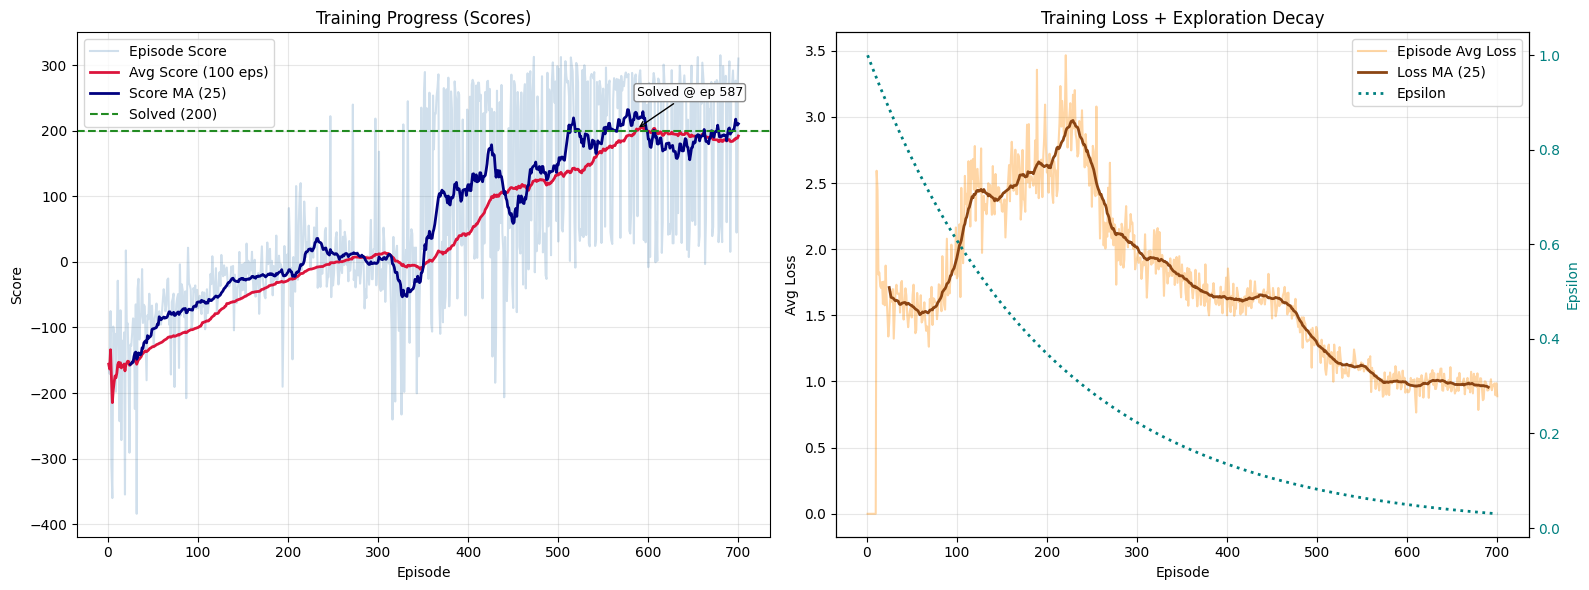

In [ ]:
def plot_training_results(scores, avg_scores, losses):
    n_episodes = len(scores)
    episodes = np.arange(1, n_episodes + 1)

    # Build a short moving-average trend
    score_window = min(PLOT_MOVING_AVG_WINDOW, n_episodes)
    score_ma = np.convolve(
        scores,
        np.ones(score_window) / score_window,
        mode="valid"
    )

    # Ignore zero placeholders from early episodes when no training step
    # occurred yet. smooth the remaining loss values
    nonzero_losses = [l for l in losses if l > 0]
    if nonzero_losses:
        loss_window = min(PLOT_MOVING_AVG_WINDOW, len(nonzero_losses))
        loss_ma = np.convolve(
            nonzero_losses,
            np.ones(loss_window) / loss_window,
            mode="valid"
        )
    else:
        loss_ma = []

    # Recreate epsilon-by-episode from the global schedule so exploration
    # can be compared directly against score/loss trends
    epsilons = []
    eps = EPSILON_START
    for _ in range(n_episodes):
        epsilons.append(eps)
        eps = max(EPSILON_END, eps * EPSILON_DECAY)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Left panel: raw scores, running average, and solved threshold
    axes[0].plot(episodes, scores, alpha=0.25, color="steelblue",
                 label="Episode Score")
    axes[0].plot(episodes, avg_scores, color="crimson", linewidth=2,
                 label="Avg Score (100 eps)")
    axes[0].plot(
        np.arange(score_window, n_episodes + 1),
        score_ma,
        color="navy",
        linewidth=2,
        label=f"Score MA ({score_window})"
    )
    axes[0].axhline(y=200, color="forestgreen", linestyle="--",
                    label="Solved (200)")

    # Mark first episode where the 100-episode mean reaches "solved" level
    solved_idx = next((i for i, s in enumerate(avg_scores) if s >= 200), None)
    if solved_idx is not None:
        axes[0].annotate(
            f"Solved @ ep {solved_idx + 1}",
            xy=(solved_idx + 1, avg_scores[solved_idx]),
            xytext=(solved_idx + 1, avg_scores[solved_idx] + 50),
            arrowprops=dict(arrowstyle="->", color="black", lw=1),
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.9)
        )

    axes[0].set_xlabel("Episode")
    axes[0].set_ylabel("Score")
    axes[0].set_title("Training Progress (Scores)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Right panel: optimization loss with epsilon on a second y-axis.
    axes[1].plot(episodes, losses, alpha=0.35, color="darkorange",
                 label="Episode Avg Loss")
    if len(loss_ma) > 0:
        axes[1].plot(
            np.arange(loss_window, loss_window + len(loss_ma)),
            loss_ma,
            color="saddlebrown",
            linewidth=2,
            label=f"Loss MA ({loss_window})"
        )

    ax_eps = axes[1].twinx()
    ax_eps.plot(episodes, epsilons, color="teal", linestyle=":", linewidth=2,
                label="Epsilon")
    ax_eps.set_ylabel("Epsilon", color="teal")
    ax_eps.tick_params(axis="y", labelcolor="teal")

    axes[1].set_xlabel("Episode")
    axes[1].set_ylabel("Avg Loss")
    axes[1].set_title("Training Loss + Exploration Decay")
    lines_l, labels_l = axes[1].get_legend_handles_labels()
    lines_r, labels_r = ax_eps.get_legend_handles_labels()
    axes[1].legend(lines_l + lines_r, labels_l + labels_r, loc="upper right")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_results(scores, avg_scores, losses)

## Evaluation (Member 2 - Nicola)

In [ ]:
def evaluate_agent(agent, num_episodes=10):
    env = gym.make("LunarLander-v3")
    test_scores = []

    # Run evaluation with no exploration and no gradient tracking
    prev_mode = agent.policy_net.training
    agent.policy_net.eval()

    for ep in range(1, num_episodes + 1):
        state, info = env.reset()
        total_reward = 0
        done = False

        while not done:
            with torch.no_grad():
                state_tensor = torch.FloatTensor(
                    state).unsqueeze(0).to(device)
                action = agent.policy_net(
                    state_tensor).argmax(dim=1).item()

            state, reward, terminated, truncated, info = \
                env.step(action)
            total_reward += reward
            done = terminated or truncated

        test_scores.append(total_reward)
        print(f"Test Episode {ep}: Score = {total_reward:.1f}")

    env.close()

    if prev_mode:
        agent.policy_net.train()

    scores_arr = np.array(test_scores, dtype=np.float32)
    solved_count = int(np.sum(scores_arr > 200))
    solved_rate = 100.0 * solved_count / max(1, num_episodes)

    print("\nEvaluation summary")
    print(f"Average: {scores_arr.mean():.1f} (+/- {scores_arr.std():.1f})")
    print(f"Median: {np.median(scores_arr):.1f}")
    print(f"Min/Max: {scores_arr.min():.1f} / {scores_arr.max():.1f}")
    print(f"Solved episodes (>200): {solved_count}/{num_episodes} ({solved_rate:.1f}%)")
    return test_scores

print("EVALUATING TRAINED AGENT")
test_scores = evaluate_agent(agent, num_episodes=10)

EVALUATING TRAINED AGENT
Test Episode 1: Score = 283.1
Test Episode 2: Score = 244.9
Test Episode 3: Score = 296.5
Test Episode 4: Score = 266.3
Test Episode 5: Score = 314.4
Test Episode 6: Score = 277.3
Test Episode 7: Score = 284.5
Test Episode 8: Score = 284.2
Test Episode 9: Score = 69.5
Test Episode 10: Score = 290.4

Evaluation summary
Average: 261.1 (+/- 66.2)
Median: 283.7
Min/Max: 69.5 / 314.4
Solved episodes (>200): 9/10 (90.0%)
